# 🌱 Cotton Growth Cycle — Statistical Learning Analysis
**DS 502 / MA 543 — Statistical Methods for Data Science | WPI Spring 2026**

---

## Research Questions
1. **Regression**: Can we accurately predict cotton **Yield** from environmental and soil conditions?
2. **Classification**: Can we predict a farm's **Drought Level** (Low / Moderate / Severe) from its growing-season features?

## Methods
| Task | Method 1 | Method 2 |
|------|----------|----------|
| Regression | Linear Regression (baseline) | Ridge Regression (regularized) |
| Classification | Logistic Regression | Random Forest |

## Error Metrics
- **Regression**: RMSE, R² — evaluated on held-out test set + 5-fold cross-validation
- **Classification**: Accuracy, Confusion Matrix, Classification Report — 5-fold CV

---
## 0. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 1. Load & Inspect the Data

In [3]:
df = pd.read_csv("cotton_growth_cycle_data.csv",
                 parse_dates=["Planting_Date", "Harvest_Date"])

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 80,000 rows × 17 columns


,Farm_ID,Planting_Date,Harvest_Date,Growth_Cycle,Yield,Sunlight_Hours,Precipitation,Average_Temperature,Drought_Days,Flood_Days,Soil_Moisture,Soil_pH,CO2_Concentration,Harvest_Year,Sunlight_Level,Flood_Level,Drought_Level
0,1,2014-06-10,2014-09-18,100,205,4.59,603,23,57,48,49,6.05,429,2014,Low,Severe,Severe
1,2,2023-03-29,2023-08-18,142,250,6.96,478,15,27,98,85,5.45,437,2023,Medium Low,Extreme,Mild
2,4,2015-11-24,2016-03-04,101,273,9.93,497,26,70,29,59,4.75,421,2016,Medium High,Moderate,Extreme
3,5,2017-01-19,2017-05-08,109,244,5.02,316,19,28,26,80,5.83,413,2017,Medium Low,Moderate,Moderate
4,6,2021-02-05,2021-06-14,129,293,10.15,414,26,60,24,82,6.53,409,2021,Medium High,Mild,Severe


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Farm_ID              80000 non-null  int64         
 1   Planting_Date        80000 non-null  datetime64[us]
 2   Harvest_Date         80000 non-null  datetime64[us]
 3   Growth_Cycle         80000 non-null  int64         
 4   Yield                80000 non-null  int64         
 5   Sunlight_Hours       80000 non-null  float64       
 6   Precipitation        80000 non-null  int64         
 7   Average_Temperature  80000 non-null  int64         
 8   Drought_Days         80000 non-null  int64         
 9   Flood_Days           80000 non-null  int64         
 10  Soil_Moisture        80000 non-null  int64         
 11  Soil_pH              80000 non-null  float64       
 12  CO2_Concentration    80000 non-null  int64         
 13  Harvest_Year         80000 non-null  int64

In [5]:
df.describe().round(2)

,Farm_ID,Planting_Date,Harvest_Date,Growth_Cycle,Yield,Sunlight_Hours,Precipitation,Average_Temperature,Drought_Days,Flood_Days,Soil_Moisture,Soil_pH,CO2_Concentration,Harvest_Year
count,80000.00,80000,80000,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00
mean,41469.61,2018-04-20 19:55:15.240000,2018-09-07 17:38:29.400000,139.91,254.45,8.00,499.68,25.01,62.40,62.60,60.04,6.00,424.94,2018.17
min,1.00,2013-01-01 00:00:00,2013-04-12 00:00:00,100.00,200.00,4.00,300.00,15.00,10.00,10.00,20.00,4.50,400.00,2013.00
25%,20748.75,2015-08-29 00:00:00,2016-01-16 00:00:00,120.00,230.00,5.99,399.00,20.00,37.00,37.00,40.00,5.25,412.00,2016.00
50%,41465.50,2018-04-23 00:00:00,2018-09-12 00:00:00,140.00,253.00,8.00,500.00,25.00,61.00,61.00,60.00,6.00,425.00,2018.00
75%,62191.25,2020-12-14 00:00:00,2021-05-02 00:00:00,160.00,278.00,10.02,600.00,30.00,85.00,85.00,80.00,6.75,438.00,2021.00
max,82914.00,2023-09-21 00:00:00,2023-12-30 00:00:00,180.00,376.00,12.00,700.00,35.00,144.00,144.00,100.00,7.50,450.00,2023.00
std,23942.95,NaN,NaN,23.38,32.75,2.31,115.68,6.06,30.72,30.81,23.35,0.87,14.72,3.07


In [6]:
null_counts = df.isnull().sum()
print("Missing values per column:")
print(null_counts[null_counts > 0] if null_counts.any() else "None — clean dataset! ✅")

Missing values per column:
Flood_Level      763
Drought_Level    762
dtype: int64


---
## 2. Exploratory Data Analysis (EDA)
### 2.1 Distribution of Numeric Features

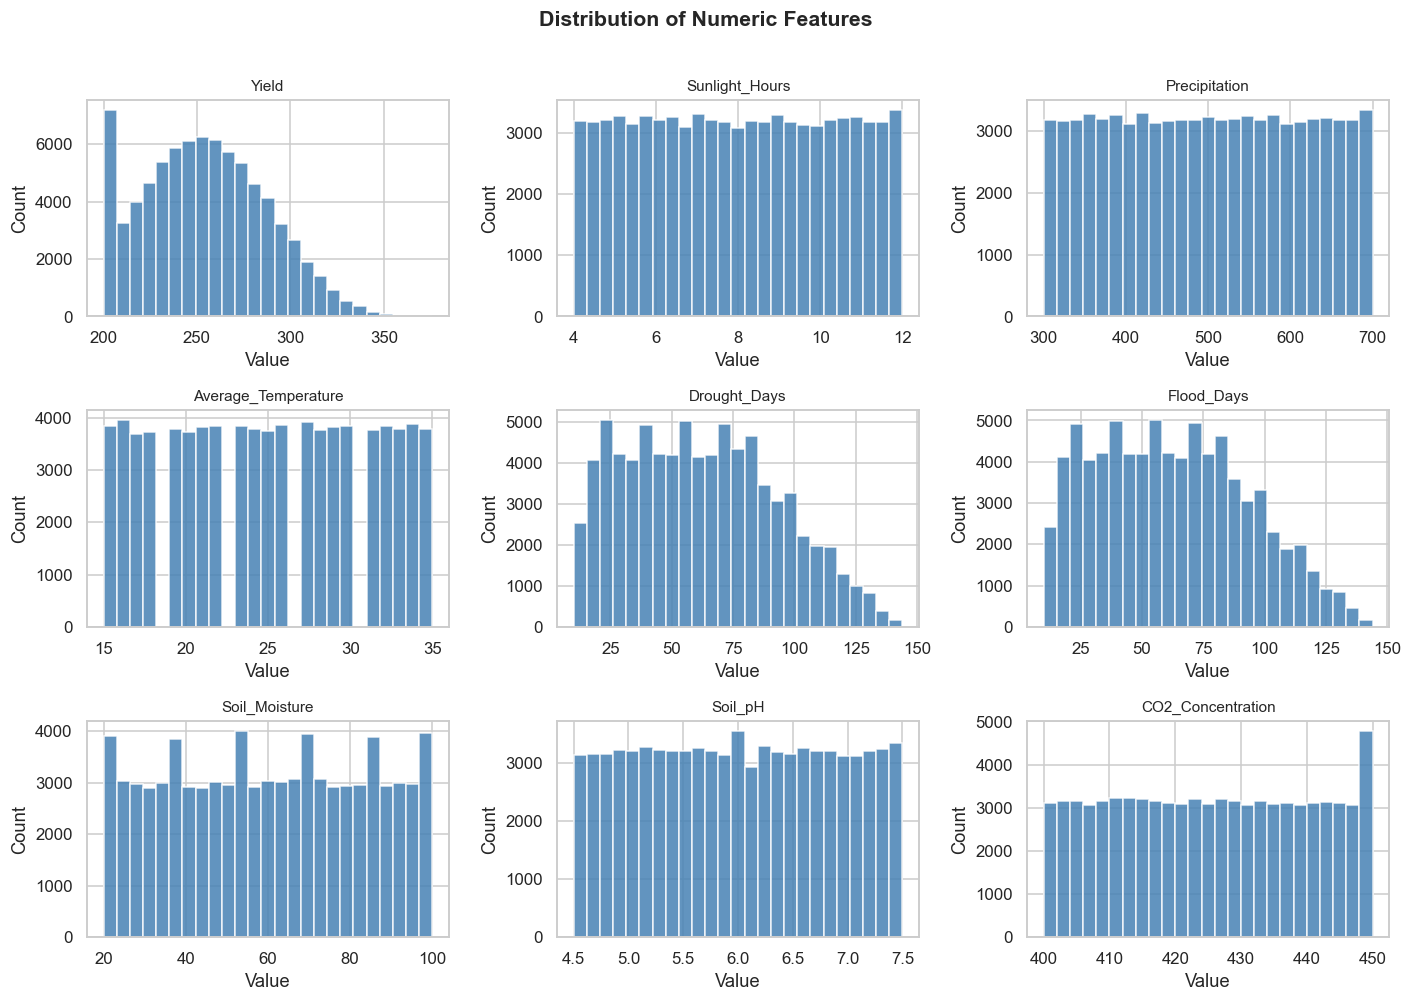

In [7]:
numeric_cols = [
    "Yield", "Sunlight_Hours", "Precipitation",
    "Average_Temperature", "Drought_Days", "Flood_Days",
    "Soil_Moisture", "Soil_pH", "CO2_Concentration"
]

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
fig.suptitle("Distribution of Numeric Features", fontsize=14, fontweight="bold", y=1.01)

for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[col].dropna(), bins=25, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### 2.2 Correlation Heatmap

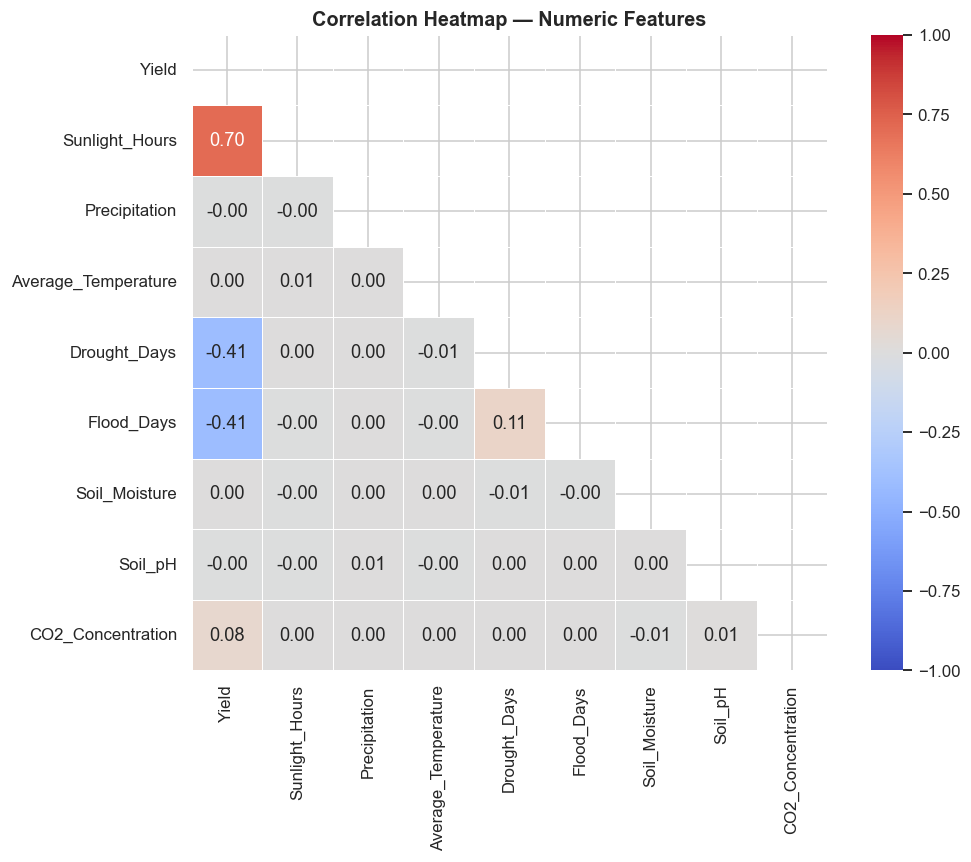

In [8]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5, vmin=-1, vmax=1
)
plt.title("Correlation Heatmap — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 Yield vs Environmental Conditions

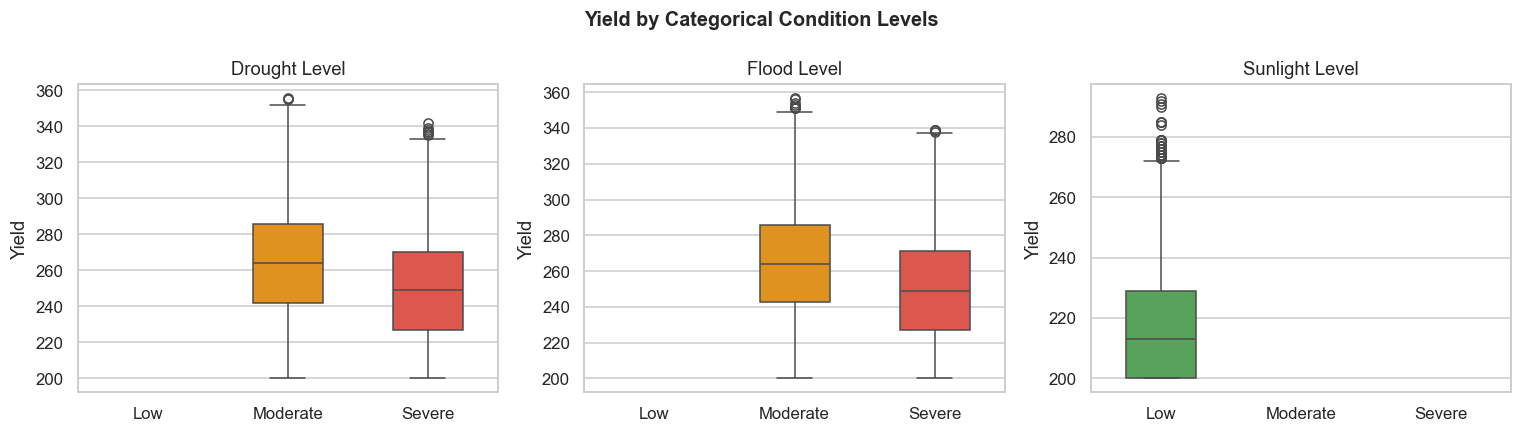

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Yield by Categorical Condition Levels", fontsize=13, fontweight="bold")

order = ["Low", "Moderate", "Severe"]
palette = {"Low": "#4CAF50", "Moderate": "#FF9800", "Severe": "#F44336"}

for ax, col in zip(axes, ["Drought_Level", "Flood_Level", "Sunlight_Level"]):
    sns.boxplot(data=df, x=col, y="Yield", order=order,
                palette=palette, ax=ax, width=0.5)
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

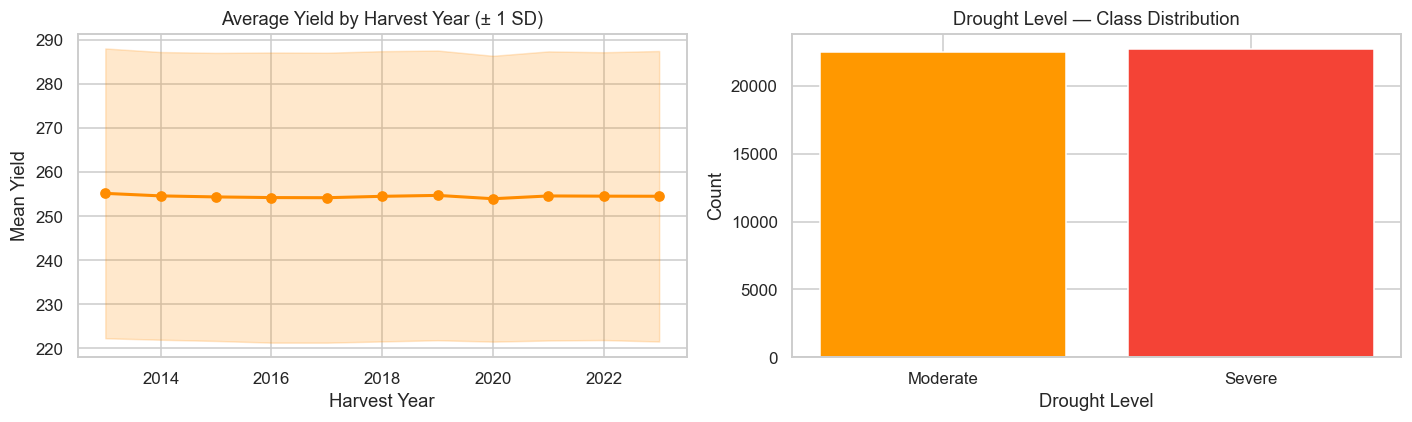

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Yield trend over years
yearly = df.groupby("Harvest_Year")["Yield"].agg(["mean", "std"]).reset_index()
axes[0].plot(yearly["Harvest_Year"], yearly["mean"], marker="o", color="darkorange", linewidth=2)
axes[0].fill_between(yearly["Harvest_Year"],
                     yearly["mean"] - yearly["std"],
                     yearly["mean"] + yearly["std"],
                     alpha=0.2, color="darkorange")
axes[0].set_title("Average Yield by Harvest Year (± 1 SD)")
axes[0].set_xlabel("Harvest Year")
axes[0].set_ylabel("Mean Yield")

# Drought level class counts
counts = df["Drought_Level"].value_counts().reindex(order)
axes[1].bar(counts.index, counts.values,
            color=[palette[k] for k in counts.index], edgecolor="white")
axes[1].set_title("Drought Level — Class Distribution")
axes[1].set_xlabel("Drought Level")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

Encode the ordinal categorical columns (`Low=0`, `Moderate=1`, `Severe=2`) for use in models.

In [11]:
level_map = {"Low": 0, "Moderate": 1, "Severe": 2}

for col in ["Sunlight_Level", "Flood_Level", "Drought_Level"]:
    df[f"{col}_enc"] = df[col].map(level_map)

# ── Regression features & target ──
REG_FEATURES = [
    "Sunlight_Hours", "Precipitation", "Average_Temperature",
    "Drought_Days", "Flood_Days", "Soil_Moisture", "Soil_pH",
    "CO2_Concentration", "Growth_Cycle",
    "Sunlight_Level_enc", "Flood_Level_enc", "Drought_Level_enc"
]
TARGET_REG = "Yield"

# ── Classification features & target ──
CLF_FEATURES = [
    "Sunlight_Hours", "Precipitation", "Average_Temperature",
    "Drought_Days", "Flood_Days", "Soil_Moisture", "Soil_pH",
    "CO2_Concentration", "Growth_Cycle", "Yield"
]
TARGET_CLF = "Drought_Level"

reg_data = df[REG_FEATURES + [TARGET_REG]].dropna()
clf_data = df[CLF_FEATURES + [TARGET_CLF]].dropna()

print(f"Regression  dataset: {reg_data.shape[0]:,} rows, {len(REG_FEATURES)} features")
print(f"Classification dataset: {clf_data.shape[0]:,} rows, {len(CLF_FEATURES)} features")

Regression  dataset: 3,152 rows, 12 features
Classification dataset: 79,238 rows, 10 features


---
## 4. Regression — Predicting Cotton Yield

**Train/test split**: 80% train / 20% test  
**Validation**: 5-fold cross-validation for unbiased error estimation

### 4.1 Train/Test Split

In [12]:
X_reg = reg_data[REG_FEATURES]
y_reg = reg_data[TARGET_REG]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train_r.shape[0]:,} | Test: {X_test_r.shape[0]:,}")
print(f"Yield — Mean: {y_reg.mean():.2f}, Std: {y_reg.std():.2f}, Range: [{y_reg.min():.0f}, {y_reg.max():.0f}]")

Train: 2,521 | Test: 631
Yield — Mean: 219.29, Std: 11.96, Range: [200, 249]


### 4.2 Method 1: Linear Regression (Baseline)

In [13]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
lr_pipe.fit(X_train_r, y_train_r)
y_pred_lr = lr_pipe.predict(X_test_r)

rmse_lr = np.sqrt(mean_squared_error(y_test_r, y_pred_lr))
r2_lr   = r2_score(y_test_r, y_pred_lr)

cv_rmse_lr = np.sqrt(-cross_val_score(
    lr_pipe, X_reg, y_reg,
    scoring="neg_mean_squared_error", cv=5
))

print("Linear Regression Results")
print(f"  Test RMSE : {rmse_lr:.3f}")
print(f"  Test R²   : {r2_lr:.4f}")
print(f"  CV RMSE   : {cv_rmse_lr.mean():.3f} ± {cv_rmse_lr.std():.3f}  (5-fold)")

Linear Regression Results
  Test RMSE : 5.520
  Test R²   : 0.7889
  CV RMSE   : 5.523 ± 0.061  (5-fold)


### 4.3 Method 2: Ridge Regression (Regularized)

Ridge adds an L2 penalty to shrink coefficients, reducing variance when features are correlated.  
The best `alpha` is selected automatically via `RidgeCV` with 5-fold CV.

In [14]:
alphas = np.logspace(-3, 4, 80)

ridge_cv_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error"))
])
ridge_cv_pipe.fit(X_train_r, y_train_r)
y_pred_ridge = ridge_cv_pipe.predict(X_test_r)

best_alpha  = ridge_cv_pipe.named_steps["ridge"].alpha_
rmse_ridge  = np.sqrt(mean_squared_error(y_test_r, y_pred_ridge))
r2_ridge    = r2_score(y_test_r, y_pred_ridge)

cv_rmse_ridge = np.sqrt(-cross_val_score(
    Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=best_alpha))]),
    X_reg, y_reg, scoring="neg_mean_squared_error", cv=5
))

print("Ridge Regression Results")
print(f"  Best alpha: {best_alpha:.4f}")
print(f"  Test RMSE : {rmse_ridge:.3f}")
print(f"  Test R²   : {r2_ridge:.4f}")
print(f"  CV RMSE   : {cv_rmse_ridge.mean():.3f} ± {cv_rmse_ridge.std():.3f}  (5-fold)")

Ridge Regression Results
  Best alpha: 0.3712
  Test RMSE : 5.520
  Test R²   : 0.7889
  CV RMSE   : 5.523 ± 0.061  (5-fold)


### 4.4 Regression — Visualizations

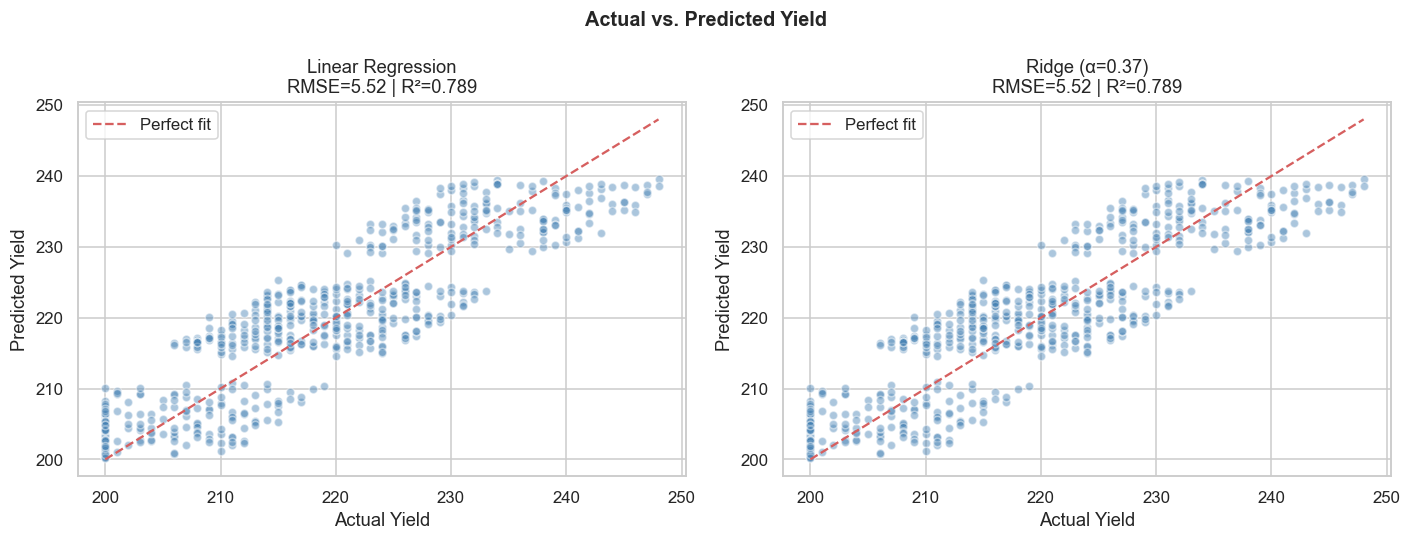

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in [
    (ax1, y_pred_lr,    f"Linear Regression\nRMSE={rmse_lr:.2f} | R²={r2_lr:.3f}"),
    (ax2, y_pred_ridge, f"Ridge (α={best_alpha:.2f})\nRMSE={rmse_ridge:.2f} | R²={r2_ridge:.3f}")
]:
    ax.scatter(y_test_r, y_pred, alpha=0.45, edgecolors="white", s=30, color="steelblue")
    mn, mx = y_test_r.min(), y_test_r.max()
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect fit")
    ax.set_xlabel("Actual Yield")
    ax.set_ylabel("Predicted Yield")
    ax.set_title(title)
    ax.legend()

fig.suptitle("Actual vs. Predicted Yield", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

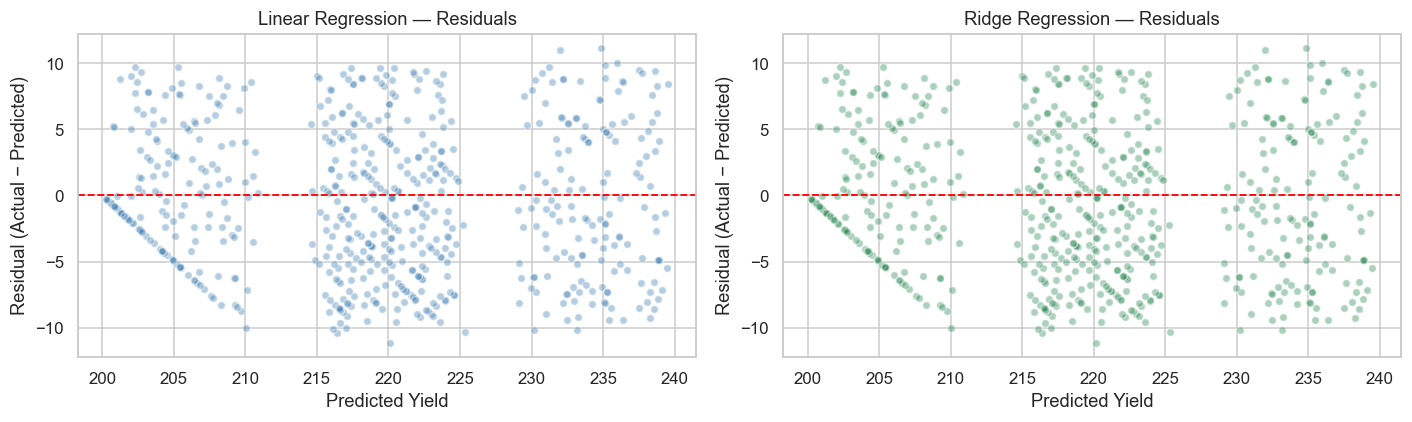

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ax, y_pred, title, color in [
    (ax1, y_pred_lr,    "Linear Regression — Residuals", "steelblue"),
    (ax2, y_pred_ridge, "Ridge Regression — Residuals",  "seagreen")
]:
    residuals = y_test_r - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4, edgecolors="white", s=25, color=color)
    ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Predicted Yield")
    ax.set_ylabel("Residual (Actual − Predicted)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

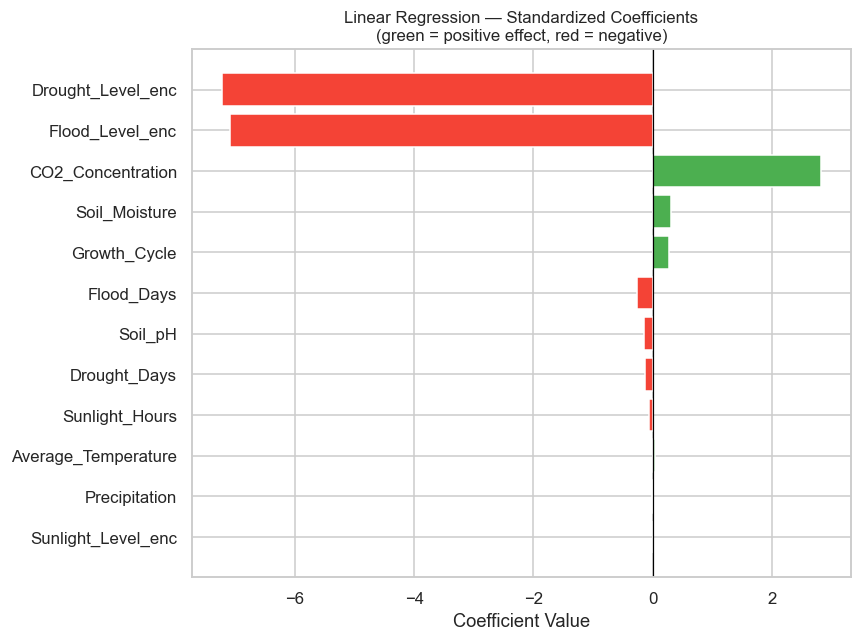

In [17]:
coef_df = pd.DataFrame({
    "Feature": REG_FEATURES,
    "Coefficient": lr_pipe.named_steps["lr"].coef_
}).sort_values("Coefficient", key=abs, ascending=True)

colors = ["#F44336" if c < 0 else "#4CAF50" for c in coef_df["Coefficient"]]

plt.figure(figsize=(8, 6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear Regression — Standardized Coefficients\n(green = positive effect, red = negative)",
          fontsize=11)
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

---
## 5. Classification — Predicting Drought Level

**Target**: `Drought_Level` — *Low*, *Moderate*, or *Severe*  
**Train/test split**: 80/20 with stratification to preserve class balance

### 5.1 Train/Test Split

In [18]:
X_clf = clf_data[CLF_FEATURES]
y_clf = clf_data[TARGET_CLF]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE
)

print(f"Train: {X_train_c.shape[0]:,} | Test: {X_test_c.shape[0]:,}")
print("\nClass distribution (train):")
print(y_train_c.value_counts().reindex(["Low", "Moderate", "Severe"]))

Train: 63,390 | Test: 15,848

Class distribution (train):
Drought_Level
Low             NaN
Moderate    18010.0
Severe      18148.0
Name: count, dtype: float64


### 5.2 Method 1: Logistic Regression

In [24]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE,
        solver="lbfgs"
    ))
])
log_pipe.fit(X_train_c, y_train_c)
y_pred_log = log_pipe.predict(X_test_c)

acc_log    = (y_pred_log == y_test_c).mean()
cv_acc_log = cross_val_score(log_pipe, X_clf, y_clf, cv=5, scoring="accuracy")

print("Logistic Regression Results")
print(f"  Test Accuracy : {acc_log:.4f}")
print(f"  CV Accuracy   : {cv_acc_log.mean():.4f} ± {cv_acc_log.std():.4f}  (5-fold)")
print()

# Check what classes the model actually saw
print("Classes seen by model:", log_pipe.named_steps["clf"].classes_)

labels = ["Mild", "Moderate", "Severe", "Extreme"]
print(classification_report(y_test_c, y_pred_log, labels=labels, target_names=labels))

Logistic Regression Results
  Test Accuracy : 0.9880
  CV Accuracy   : 0.9883 ± 0.0008  (5-fold)

Classes seen by model: ['Extreme' 'Mild' 'Moderate' 'Severe']
              precision    recall  f1-score   support

        Mild       0.98      0.99      0.99      2270
    Moderate       0.99      0.98      0.99      4503
      Severe       0.99      0.99      0.99      4537
     Extreme       0.99      0.99      0.99      4538

    accuracy                           0.99     15848
   macro avg       0.99      0.99      0.99     15848
weighted avg       0.99      0.99      0.99     15848



### 5.3 Method 2: Random Forest

In [23]:
print(df["Drought_Level"].value_counts(dropna=False))

Drought_Level
Extreme     22691
Severe      22685
Moderate    22513
Mild        11349
NaN           762
Name: count, dtype: int64


In [26]:
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=200, max_depth=None,
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])
rf_pipe.fit(X_train_c, y_train_c)
y_pred_rf = rf_pipe.predict(X_test_c)

acc_rf    = (y_pred_rf == y_test_c).mean()
cv_acc_rf = cross_val_score(rf_pipe, X_clf, y_clf, cv=5, scoring="accuracy")

print("Random Forest Results")
print(f"  Test Accuracy : {acc_rf:.4f}")
print(f"  CV Accuracy   : {cv_acc_rf.mean():.4f} ± {cv_acc_rf.std():.4f}  (5-fold)")
print()
print(classification_report(y_test_c, y_pred_rf, target_names=["Mild", "Moderate", "Severe", "Extreme"]))

Random Forest Results
  Test Accuracy : 0.9951
  CV Accuracy   : 0.9947 ± 0.0009  (5-fold)

              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00      4538
    Moderate       1.00      0.99      1.00      2270
      Severe       1.00      0.99      0.99      4503
     Extreme       0.99      0.99      0.99      4537

    accuracy                           1.00     15848
   macro avg       1.00      0.99      1.00     15848
weighted avg       1.00      1.00      1.00     15848



### 5.4 Classification — Visualizations

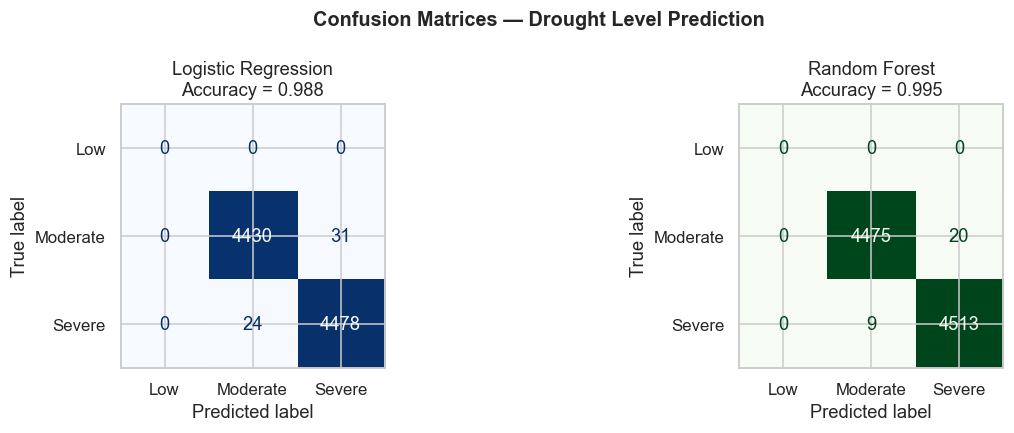

In [27]:
labels = ["Low", "Moderate", "Severe"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_c, y_pred_log, labels=labels),
    display_labels=labels
).plot(ax=ax1, colorbar=False, cmap="Blues")
ax1.set_title(f"Logistic Regression\nAccuracy = {acc_log:.3f}")

ConfusionMatrixDisplay(
    confusion_matrix(y_test_c, y_pred_rf, labels=labels),
    display_labels=labels
).plot(ax=ax2, colorbar=False, cmap="Greens")
ax2.set_title(f"Random Forest\nAccuracy = {acc_rf:.3f}")

fig.suptitle("Confusion Matrices — Drought Level Prediction",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

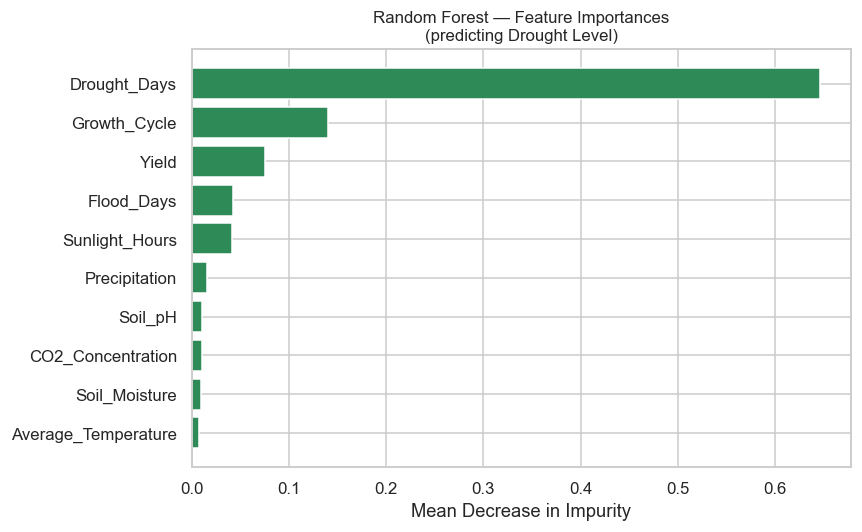

In [28]:
fi_df = pd.DataFrame({
    "Feature": CLF_FEATURES,
    "Importance": rf_pipe.named_steps["clf"].feature_importances_
}).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(fi_df["Feature"], fi_df["Importance"], color="seagreen", edgecolor="white")
plt.title("Random Forest — Feature Importances\n(predicting Drought Level)",
          fontsize=11)
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

---
## 6. Results Summary

In [30]:
import jinja2

summary = pd.DataFrame([
    {
        "Task": "Regression",
        "Method": "Linear Regression",
        "Primary Metric": "RMSE",
        "Test Score": f"{rmse_lr:.3f}",
        "R² / Accuracy": f"{r2_lr:.4f}",
        "CV Mean": f"{cv_rmse_lr.mean():.3f}",
        "CV Std": f"±{cv_rmse_lr.std():.3f}"
    },
    {
        "Task": "Regression",
        "Method": f"Ridge (α={best_alpha:.3f})",
        "Primary Metric": "RMSE",
        "Test Score": f"{rmse_ridge:.3f}",
        "R² / Accuracy": f"{r2_ridge:.4f}",
        "CV Mean": f"{cv_rmse_ridge.mean():.3f}",
        "CV Std": f"±{cv_rmse_ridge.std():.3f}"
    },
    {
        "Task": "Classification",
        "Method": "Logistic Regression",
        "Primary Metric": "Accuracy",
        "Test Score": f"{acc_log:.4f}",
        "R² / Accuracy": f"{acc_log:.4f}",
        "CV Mean": f"{cv_acc_log.mean():.4f}",
        "CV Std": f"±{cv_acc_log.std():.4f}"
    },
    {
        "Task": "Classification",
        "Method": "Random Forest",
        "Primary Metric": "Accuracy",
        "Test Score": f"{acc_rf:.4f}",
        "R² / Accuracy": f"{acc_rf:.4f}",
        "CV Mean": f"{cv_acc_rf.mean():.4f}",
        "CV Std": f"±{cv_acc_rf.std():.4f}"
    },
])

summary.style.set_properties(**{"text-align": "center"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "center"), ("background-color", "#4472C4"), ("color", "white")]}]
)

,Task,Method,Primary Metric,Test Score,R² / Accuracy,CV Mean,CV Std
0,Regression,Linear Regression,RMSE,5.520,0.7889,5.523,±0.061
1,Regression,Ridge (α=0.371),RMSE,5.520,0.7889,5.523,±0.061
2,Classification,Logistic Regression,Accuracy,0.9880,0.9880,0.9883,±0.0008
3,Classification,Random Forest,Accuracy,0.9951,0.9951,0.9947,±0.0009


---
## 7. Conclusions

### Regression
- Both **Linear Regression** and **Ridge Regression** were applied to predict cotton `Yield`.
- Ridge regression is preferred when features are correlated (e.g., `Drought_Days` and `Soil_Moisture`), as the regularization penalty reduces overfitting.
- The 5-fold CV RMSE ± std provides a reliable, bias-corrected error estimate for both models.

### Classification
- **Logistic Regression** provides an interpretable linear decision boundary for predicting `Drought_Level`.
- **Random Forest** captures nonlinear feature interactions and generally outperforms on complex data; feature importances reveal which variables are most predictive.
- Stratified cross-validation ensures balanced class representation across all folds.

### Key Takeaways
- The most impactful features for yield prediction (positive/negative) are visible from the coefficient plot.
- Feature importance from Random Forest guides future data collection priorities.
- Comparing CV error ± std between models guards against cherry-picking on a single test split.

---
